In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# PATHS
# ============================================================

results_dir = Path("../data/processed/new_diff")


# ============================================================
# LOAD PyDESeq2 RESULTS
# ============================================================

classical = pd.read_csv(
    results_dir / "CPTAC_Classical_vs_GTEx7_PyDESeq2_results.csv"
)

proneural = pd.read_csv(
    results_dir / "CPTAC_Proneural_vs_GTEx7_PyDESeq2_results.csv"
)

mesenchymal = pd.read_csv(
    results_dir / "CPTAC_Mesenchymal_vs_GTEx7_PyDESeq2_results.csv"
)


# ============================================================
# PREPARE RESULTS FOR VOLCANO PLOT
# ============================================================

def prepare_volcano(results):

    df = results.copy()

    # Remove genes without usable statistics
    df = df.dropna(
        subset=["log2FC", "FDR"]
    )

    # Avoid -log10(0)
    df["FDR"] = df["FDR"].clip(
        lower=np.finfo(float).tiny
    )

    df["-log(adjustedp)"] = (
        -np.log10(df["FDR"])
    )

    # Categories
    df["category"] = "Not Significant"

    df.loc[
        (df["FDR"] < 0.05)
        & (df["log2FC"] > 1),
        "category"
    ] = "Up"

    df.loc[
        (df["FDR"] < 0.05)
        & (df["log2FC"] < -1),
        "category"
    ] = "Down"

    return df


# ============================================================
# PREPARE ALL THREE
# ============================================================

classical_plot = prepare_volcano(classical).set_index("gene_name")

proneural_plot = prepare_volcano(proneural).set_index("gene_name")
mesenchymal_plot = prepare_volcano(mesenchymal).set_index("gene_name")


classical_plot.to_csv("../data/processed/new_diff/CPTAC_Classical_vs_GTEx7_PyDESeq2_results.csv")
proneural_plot.to_csv("../data/processed/new_diff/CPTAC_Proneural_vs_GTEx7_PyDESeq2_results.csv")
mesenchymal_plot.to_csv("../data/processed/new_diff/CPTAC_Mesenchymal_vs_GTEx7_PyDESeq2_results.csv")

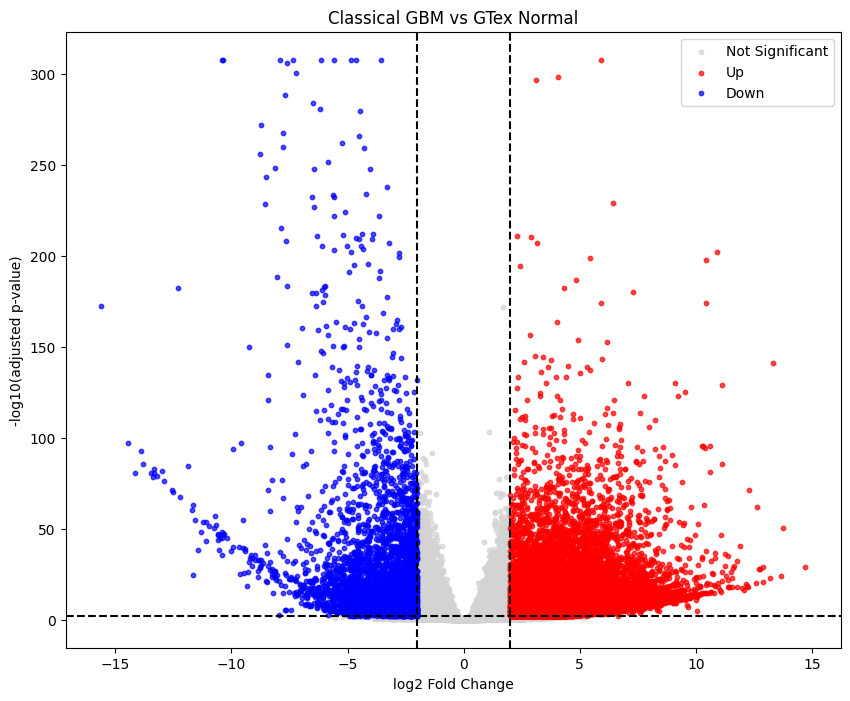

In [6]:
import sys
sys.path.append("../src")

import diff
import importlib

importlib.reload(diff)

diff.volcano_plot(classical_plot,"Classical GBM vs GTex Normal")

Classical samples: 25
['C3L-00365', 'C3L-01040', 'C3L-01048', 'C3L-01061', 'C3L-01154', 'C3L-01155', 'C3L-01156', 'C3L-01327', 'C3L-01887', 'C3L-02642', 'C3L-02707', 'C3L-03266', 'C3L-03387', 'C3L-03390', 'C3L-03681', 'C3L-04084', 'C3N-01196', 'C3N-01334', 'C3N-01368', 'C3N-01517', 'C3N-01852', 'C3N-01857', 'C3N-02782', 'C3N-03184', 'C3N-03188']

GTEx controls: 7


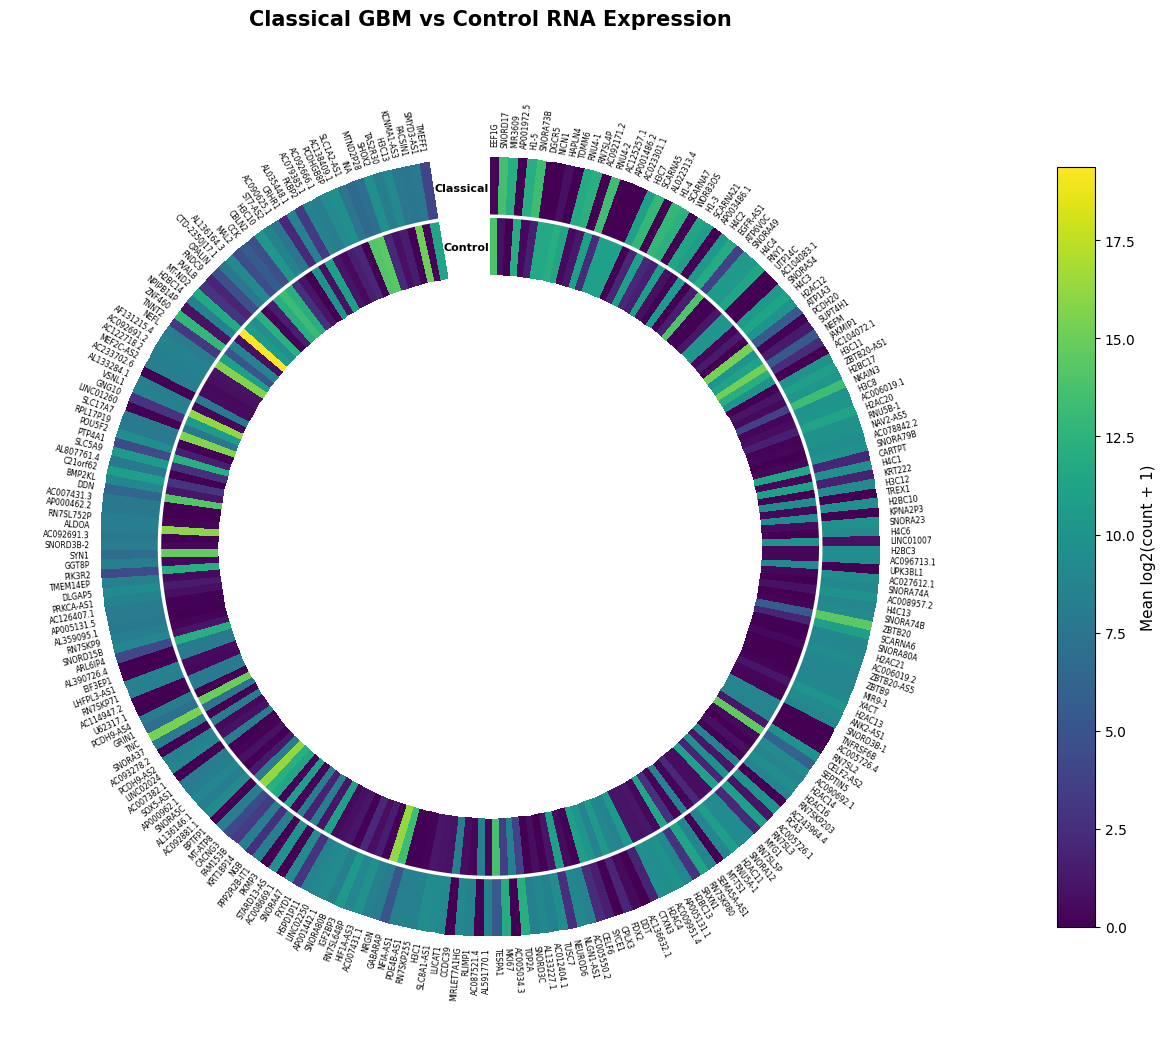

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from pathlib import Path


# ============================================================
# PATHS
# ============================================================

cptac_file = Path(
    "../data/processed/CPTAC_GBM_tumor_raw_counts.csv"
)

gtex_file = Path(
    "../data/processed/GTEx_7_normal_frontal_cortex_raw_counts.csv"
)

subtype_file = Path(
    "../data/raw/all_subtypes.v5.1.tsv"
)


# ============================================================
# LOAD CPTAC
# ============================================================

cptac = pd.read_csv(
    cptac_file,
    index_col=0
)

cptac.index = (
    cptac.index
    .astype(str)
    .str.split(".")
    .str[0]
)


# Remove duplicate genes
cptac = cptac[
    ~cptac.index.duplicated(
        keep="first"
    )
]


# ============================================================
# LOAD GTEx
# ============================================================

gtex = pd.read_csv(
    gtex_file
)

gtex["Name"] = (
    gtex["Name"]
    .astype(str)
    .str.split(".")
    .str[0]
)

gtex = gtex.set_index(
    "Name"
)

if "Description" in gtex.columns:
    gtex = gtex.drop(
        columns="Description"
    )


gtex = gtex[
    ~gtex.index.duplicated(
        keep="first"
    )
]


# ============================================================
# COMMON GENES
# ============================================================

common_genes = (
    cptac.index
    .intersection(gtex.index)
)

cptac = cptac.loc[
    common_genes
]

gtex = gtex.loc[
    common_genes
]


# ============================================================
# LOAD SUBTYPE INFORMATION
# ============================================================

subtypes = pd.read_csv(
    subtype_file,
    sep="\t"
)

subtypes = subtypes.rename(
    columns={
        subtypes.columns[0]: "sample"
    }
)

subtypes["sample"] = (
    subtypes["sample"]
    .astype(str)
    .str.strip()
)


# ============================================================
# SELECT CLASSICAL SAMPLES
# ============================================================

classical_samples = subtypes.loc[
    subtypes["rna_wang_cancer_cell_2017"]
    == "Classical",
    "sample"
].tolist()


# Only retain samples actually present in counts
classical_samples = [
    sample
    for sample in classical_samples
    if sample in cptac.columns
]


print(
    "Classical samples:",
    len(classical_samples)
)

print(
    classical_samples
)


# ============================================================
# SELECT GTEx CONTROLS
# ============================================================

normal_samples = gtex.columns.tolist()


print(
    "\nGTEx controls:",
    len(normal_samples)
)


# ============================================================
# EXPRESSION MATRICES
# ============================================================

gbm_expr = cptac[
    classical_samples
].copy()

normal_expr = gtex[
    normal_samples
].copy()


# ============================================================
# LOG2 TRANSFORMATION
# ============================================================

# Raw RNA-seq counts are highly right-skewed.
# log2(count + 1) makes the expression values more suitable
# for visualization.

gbm_expr = np.log2(
    gbm_expr + 1
)

normal_expr = np.log2(
    normal_expr + 1
)


# ============================================================
# MEAN EXPRESSION
# ============================================================

avg_norm = normal_expr.mean(
    axis=1
)

avg_clas = gbm_expr.mean(
    axis=1
)


plot_df = pd.DataFrame({
    "Control": avg_norm,
    "Classical": avg_clas
}).dropna()


# ============================================================
# SELECT GENES
# ============================================================

n_genes = 250

plot_df["abs_diff"] = (
    plot_df["Classical"]
    - plot_df["Control"]
).abs()


plot_df = (
    plot_df
    .sort_values(
        "abs_diff",
        ascending=False
    )
    .head(n_genes)
    .drop(
        columns="abs_diff"
    )
)


# ============================================================
# GENE NAMES
# ============================================================

# At this point the index is still Ensembl IDs.
#
# If you have already created a gene_mapping dataframe
# containing:
#
#     gene_id
#     gene_name
#
# use it here.

original_cptac = pd.read_csv('../data/raw/CPTAC_GBM/0a14b390-558e-418a-83f8-148f459f2855/fdaad4b3-332b-4187-8e0d-c2f639add45c.rna_seq.augmented_star_gene_counts.tsv',skiprows=1,sep="\t")

gene_mapping = original_cptac[
    [
        "gene_id",
        "gene_name"
    ]
].copy()

gene_mapping["gene_id"] = (
    gene_mapping["gene_id"]
    .astype(str)
    .str.split(".")
    .str[0]
)

gene_mapping["gene_name"] = (
    gene_mapping["gene_name"]
    .astype(str)
    .str.strip()
)

gene_mapping = gene_mapping.drop_duplicates(
    subset="gene_id"
)


# Map Ensembl -> gene name
gene_name_dict = dict(
    zip(
        gene_mapping["gene_id"],
        gene_mapping["gene_name"]
    )
)


plot_df["gene_name"] = [
    gene_name_dict.get(
        gene,
        gene
    )
    for gene in plot_df.index
]


# ============================================================
# MATRIX
# ============================================================

# Row 0 = Control
# Row 1 = Classical

Z = plot_df[
    [
        "Control",
        "Classical"
    ]
].T.to_numpy()

n_rings, n_cols = Z.shape

gene_names = (
    plot_df["gene_name"]
    .astype(str)
    .tolist()
)


# ============================================================
# CIRCULAR GEOMETRY
# ============================================================

gap_ratio = 0.025

full_circle = 2 * np.pi

theta_start = 0

theta_end = (
    full_circle *
    (1 - gap_ratio)
)

theta_edges = np.linspace(
    theta_start,
    theta_end,
    n_cols + 1
)


# ============================================================
# RING SIZE
# ============================================================

inner_radius = 3.0

ring_width = 0.65

middle_radius = (
    inner_radius +
    ring_width
)

outer_radius = (
    middle_radius +
    ring_width
)


r = np.array([
    inner_radius,
    middle_radius,
    outer_radius
])


T, R = np.meshgrid(
    theta_edges,
    r
)


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 14),
    subplot_kw={
        "projection": "polar"
    }
)

ax.set_theta_direction(-1)

ax.set_theta_offset(
    np.pi / 2
)


# ============================================================
# EXPRESSION COLOR SCALE
# ============================================================

norm = Normalize(
    vmin=np.nanmin(Z),
    vmax=np.nanmax(Z)
)

cmap = plt.cm.viridis


mesh = ax.pcolormesh(
    T,
    R,
    Z,
    cmap=cmap,
    norm=norm,
    shading="flat"
)


# ============================================================
# CONTROL / CLASSICAL SEPARATOR
# ============================================================

theta_line = np.linspace(
    theta_start,
    theta_end,
    1000
)

ax.plot(
    theta_line,
    np.full_like(
        theta_line,
        middle_radius
    ),
    color="white",
    linewidth=2.5,
    zorder=10
)


# ============================================================
# AXIS LIMITS
# ============================================================

label_radius = (
    outer_radius +
    0.55
)

ax.set_ylim(
    0,
    label_radius + 0.45
)


# ============================================================
# REMOVE POLAR AXIS
# ============================================================

ax.set_xticks([])

ax.set_yticks([])

ax.grid(False)

ax.spines[
    "polar"
].set_visible(False)


# ============================================================
# SAMPLE LABELS
# ============================================================

gap_angle = (
    theta_end +
    full_circle
) / 2


# Classical

ax.text(
    gap_angle,
    middle_radius +
    ring_width * 0.5,
    "Classical",
    ha="center",
    va="center",
    fontsize=8,
    fontweight="bold"
)


# Control

ax.text(
    gap_angle,
    inner_radius +
    ring_width * 0.5,
    "Control",
    ha="center",
    va="center",
    fontsize=8,
    fontweight="bold"
)


# ============================================================
# GENE LABELS
# ============================================================

label_radius = (
    outer_radius +
    0.12
)


for i, gene in enumerate(
    gene_names
):

    angle = (
        theta_edges[i] +
        theta_edges[i + 1]
    ) / 2


    visual_angle = (
        90 -
        np.degrees(angle)
    )

    visual_angle = (
        visual_angle %
        360
    )


    rotation = visual_angle


    if (
        90 <
        visual_angle <
        270
    ):

        rotation += 180

        ha = "right"

    else:

        ha = "left"


    ax.text(
        angle,
        label_radius,
        gene,
        rotation=rotation,
        rotation_mode="anchor",
        ha=ha,
        va="center",
        fontsize=5.5,
        clip_on=False
    )


# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    mesh,
    ax=ax,
    fraction=0.035,
    pad=0.08,
    shrink=0.75
)

cbar.set_label(
    "Mean log2(count + 1)",
    fontsize=11
)


# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Classical GBM vs Control RNA Expression",
    fontsize=15,
    fontweight="bold",
    pad=30
)


# ============================================================
# SAVE
# ============================================================

output_path = (
    "../data/interim/network_stat/"
    "classical_normal_vs_classical_circular_heatmap.svg"
)

plt.savefig(
    output_path,
    format="svg",
    bbox_inches="tight"
)


plt.show()